In [1]:
import glob
import re
import pandas as pd

pattern = "../docking_results_3oxz/lig_*_out.pdbqt"
files = glob.glob(pattern)

results = []
for file in files:
    with open(file, 'r') as f:
        for line in f:
            if line.startswith("REMARK VINA RESULT:"):
                parts = line.split()
                match = re.search(r'REMARK VINA RESULT:\s+([-\d.]+)', line)
                if match:
                    value = float(match.group(1))
                    results.append({'file': file, 'value': value})
                break

df = pd.DataFrame(results)
print(df)

                                        file   value
0   ../docking_results_3oxz\lig_10_out.pdbqt  -8.843
1   ../docking_results_3oxz\lig_11_out.pdbqt  -9.627
2   ../docking_results_3oxz\lig_12_out.pdbqt  -9.920
3   ../docking_results_3oxz\lig_13_out.pdbqt -10.010
4   ../docking_results_3oxz\lig_14_out.pdbqt  -9.645
5   ../docking_results_3oxz\lig_15_out.pdbqt  -8.545
6   ../docking_results_3oxz\lig_16_out.pdbqt  -8.160
7   ../docking_results_3oxz\lig_17_out.pdbqt  -8.873
8   ../docking_results_3oxz\lig_19_out.pdbqt  -8.791
9    ../docking_results_3oxz\lig_1_out.pdbqt  -9.388
10  ../docking_results_3oxz\lig_20_out.pdbqt  -8.679
11  ../docking_results_3oxz\lig_21_out.pdbqt  -9.504
12  ../docking_results_3oxz\lig_22_out.pdbqt  -9.978
13  ../docking_results_3oxz\lig_23_out.pdbqt  -9.736
14  ../docking_results_3oxz\lig_24_out.pdbqt  -8.345
15  ../docking_results_3oxz\lig_25_out.pdbqt  -8.585
16  ../docking_results_3oxz\lig_26_out.pdbqt  -7.998
17  ../docking_results_3oxz\lig_27_out.pdbqt -

In [2]:
print('min:', df['value'].min())
print('max:', df['value'].max())
print('mean:', df['value'].mean())

min: -11.305
max: -7.016
mean: -9.19662962962963


In [3]:
df_result = pd.read_csv('valid_smiles_data_energy.csv')
print(df_result)

        Unnamed: 0  energy                                             smiles  \
0                0    -9.4            c1ccc(Nc2nc(OCC3CCCCC3)c3[nH]cnc3n2)cc1   
1                1    -9.7      Cc1ccc(NC(=O)c2cccnc2)cc1Nc1nccc(-c2cccnc2)n1   
2                3    -9.3  NS(=O)(=O)c1ccc(Nc2nc(OCC3CCCCC3)c3[nH]cnc3n2)cc1   
3                4   -10.7  Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...   
4                5    -9.5                 O=C(O)c1ccccc1Nc1ccnc(Nc2ccccc2)n1   
...            ...     ...                                                ...   
112615      143327   -10.7      Cc1ccc(Nc2nc(Nc3cnc4ccccc4c3)c3[nH]cnc3n2)cc1   
112616      143329    -9.4  O=S(=O)(Nc1ncccn1)c1ccc(Nc2nc(N3CCOCC3)c3ccccc...   
112617      143331   -10.6              Oc1cccc(Nc2nccc(-c3ccc4ccccc4c3)n2)c1   
112618      143333    -9.0  N#CCCn1cc(-c2nc(Nc3ccc4c(ccn4S(=O)(=O)C(F)(F)F...   
112619      143334    -9.0  COc1cc2c(cc1Nc1ncc(C(N)=O)c(Nc3ccccc3)n1)CN(C)CC2   

              cid  
0      

In [4]:
print('min:', df_result['energy'].min())
print('max:', df_result['energy'].max())
print('mean:', df_result['energy'].mean())

min: -14.3
max: -9.0
mean: -9.772700230864855


In [5]:
print('Результаты:')
print('min:', df['value'].min())
print('max:', df['value'].max())
print('mean:', df['value'].mean())
print('Датасет')
print('min:', df_result['energy'].min())
print('max:', df_result['energy'].max())
print('mean:', df_result['energy'].mean())

Результаты:
min: -11.305
max: -7.016
mean: -9.19662962962963
Датасет
min: -14.3
max: -9.0
mean: -9.772700230864855


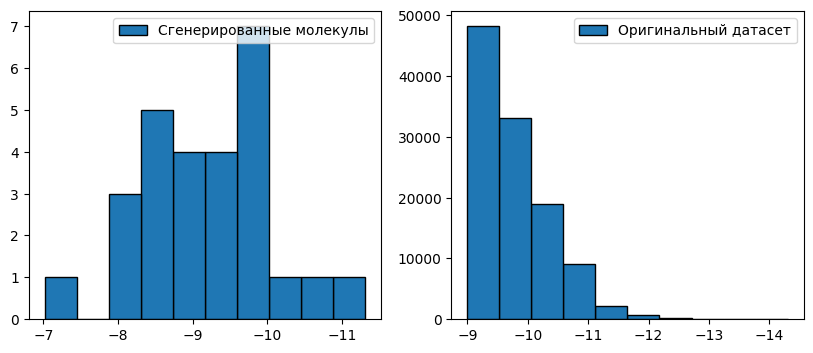

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.hist(df['value'], edgecolor='black', label='Сгенерированные молекулы')
ax2.hist(df_result['energy'], edgecolor='black',  label='Оригинальный датасет')
ax1.invert_xaxis()
ax2.invert_xaxis()
ax1.legend()
ax2.legend()
plt.show()